In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
scheme = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Files Loaded Successfully")

Files Loaded Successfully


In [5]:
print("NAV Columns:")
print(nav.columns.tolist())

print("\nInvestor Columns:")
print(investor.columns.tolist())

print("\nPortfolio Columns:")
print(portfolio.columns.tolist())

print("\nScheme Columns:")
print(scheme.columns.tolist())

NAV Columns:
['amfi_code', 'date', 'nav']

Investor Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Portfolio Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Scheme Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [6]:
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [7]:
var_cvar = nav.groupby('amfi_code')['daily_return'].apply(
    lambda x: pd.Series({
        'VaR_95': x.quantile(0.05),
        'CVaR_95': x[x <= x.quantile(0.05)].mean()
    })
).unstack()

var_cvar.to_csv('../reports/var_cvar_report.csv')

print(var_cvar.head())

             VaR_95   CVaR_95
amfi_code                    
100016    -0.014364 -0.018060
100025    -0.003793 -0.004994
100033    -0.019034 -0.023456
101206    -0.013282 -0.017439
101207    -0.026021 -0.032459


In [8]:
nav['date'] = pd.to_datetime(nav['date'])

rolling_sharpe = (
    nav.groupby('amfi_code')['daily_return']
    .rolling(90)
    .mean()
    .div(
        nav.groupby('amfi_code')['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)
)

rolling_sharpe = rolling_sharpe.reset_index()
print(rolling_sharpe.head())

   amfi_code  level_1  daily_return
0     100016     5750           NaN
1     100016     5751           NaN
2     100016     5752           NaN
3     100016     5753           NaN
4     100016     5754           NaN


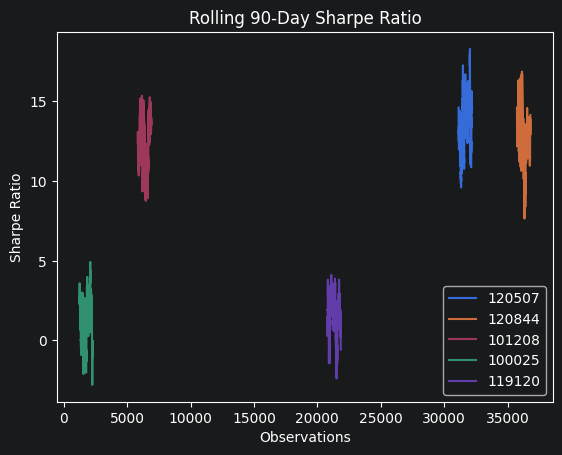

In [9]:
top5 = scheme.sort_values('sharpe_ratio', ascending=False).head(5)

for fund in top5['amfi_code']:
    temp = rolling_sharpe[rolling_sharpe['amfi_code'] == fund]
    plt.plot(temp.index, temp['daily_return'], label=str(fund))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Observations")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

In [10]:
risk_level = "High"

recommendations = (
    scheme[scheme['risk_grade'] == risk_level]
    .sort_values('sharpe_ratio', ascending=False)
    [['scheme_name', 'sharpe_ratio']]
    .head(3)
)

print(recommendations)

                                      scheme_name  sharpe_ratio
21  Kotak Emerging Equity Fund - Regular - Growth          0.96
12       ICICI Pru Midcap Fund - Regular - Growth          0.95
38             DSP Midcap Fund - Regular - Growth          0.90
